# Unsupervised Folded-Spectrum Baseline for the Kitaev-Chain Spectral Problem

## I. Introduction

This notebook is the soft-constraint baseline of the project's four-model
study of the 1D Kitaev chain. A single-head sinusoidal network (SIREN) maps
the chemical potential $\mu$ to a Nambu-basis Bogoliubov--de Gennes (BdG)
eigenvector; the energy is read off afterwards as the Rayleigh quotient.
Training is label-free: the objective is the folded-spectrum residual on
$H(\mu)$ together with three soft corrections -- a Rayleigh-variance term, an
annealed non-negativity pin, and a particle--hole residual.

It is the reference the structural notebooks are measured against. The
chiral-basis notebook makes the particle--hole pairing, the eigenvector
normalisation, and the energy sign exact by construction and is left with a
two-term, schedule-free loss; here every one of those is instead a soft
penalty, and one of them (`loss_ph`) turns out to be numerically identical
to another (`loss_var`). Making that visible is the point of this notebook.
The collocation domain $-4t < \mu < 4t$, the two-stage optimiser, and the
evaluation probe are the same as in the other two notebooks, so the three
models produce a directly comparable table.

## II. Formalism

### A. BdG Hamiltonian in the Nambu basis

In the Nambu basis
$\Psi = (c_1,\dots,c_N,c_1^\dagger,\dots,c_N^\dagger)^{\mathsf T}$ the BdG
Hamiltonian is a real symmetric $2N \times 2N$ matrix, linear in $\mu$,

$$
H(\mu) \;=\; H_{\mathrm{base}} \;+\; \mu\, H_{\mu\text{-diag}}
\;=\;
\begin{pmatrix} A(\mu) & B \\[2pt] B^{\mathsf T} & -A(\mu) \end{pmatrix},
\tag{1}
$$

with $A(\mu)$ carrying the on-site potential and the hopping and $B$ the
$p$-wave pairing. Particle--hole conjugation
$\Xi\,H(\mu)\,\Xi = -H(\mu)$ holds identically, with
$\Xi = \tau_x \otimes \mathbb{1}_N$ (real, symmetric, orthogonal). This
single identity is what makes `loss_ph` below redundant.

### B. Spectral target and the near-zero degeneracy

The learning target is the lowest non-negative eigenvalue $E(\mu)$ of
$H(\mu)$ and its eigenvector $\psi(\mu) = (u, w)$ (particle, hole blocks).
Throughout the topological phase $|\mu| < 2t$ this eigenvalue is a near-zero
mode with an edge-localised eigenvector -- the Majorana signature -- and in
the trivial phase $|\mu| > 2t$ it rises as $E \to |\mu| - 2t$. Deep in the
topological phase the $\pm\lambda_1$ pair is degenerate below floating-point
precision, so `numpy.linalg.eigh` returns an arbitrary rotation within the
two-dimensional near-zero eigenspace; eigenvector accuracy is measured as
the projection norm onto that span, not a single-vector overlap.

### C. The folded-spectrum method

Minimising $\big\langle \lVert H(\mu)\,\psi \rVert^2 \big\rangle$ over the
unit sphere drives $\psi$ onto the eigenvector of the eigenvalue nearest
zero: no shift or target energy is needed, $0$ is always the target. This is
`loss_fsm`. Its value at the exact answer is
$\big\langle \lambda_1(\mu)^2 \big\rangle$, which is **nonzero** because the
trivial-phase gap is of order $t$. The total loss therefore plateaus on this
floor while the true solution keeps improving -- the reason the probe of
Sec. VII exists.

### D. What the folded spectrum leaves undetermined, and the three corrections

`loss_fsm` alone asks only that $\lVert H\psi \rVert$ be small. It does not
force $\psi$ to be an eigenvector, does not fix the sign of the energy, and
does not tie the $-E$ partner to $\Xi\psi$. `PinnedFSMLoss` adds:

- **`loss_var` $= \big\langle \lVert H\psi - E_R\,\psi \rVert^2 \big\rangle$**,
  with $E_R = \psi^{\mathsf T} H \psi$ the Rayleigh quotient. Forces $\psi$
  to be a genuine eigenvector; near a gap-closing this differs materially
  from `loss_fsm`.
- **`loss_pin` $= \big\langle \operatorname{softplus}(-E_R,\,\beta=10)
  \big\rangle$**. `loss_fsm + loss_var` is invariant under
  $\psi \to \Xi\psi$ (which sends $E_R \to -E_R$), so the objective does not
  distinguish the $+E_R$ from the $-E_R$ branch. The pin softly rewards
  $E_R \ge 0$. Its weight anneals $1.0 \to 0.01$ over `anneal_duration`
  epochs, because $E_R$ is meaningless while $\psi$ is near-random.
- **`loss_ph` $= \big\langle \lVert H(\Xi\psi) + E_R\,(\Xi\psi) \rVert^2
  \big\rangle$**, fixed weight $0.1$. Nominally enforces the $\Xi$-partner
  relation. But $\Xi H \Xi = -H$ and $\Xi$ orthogonal give
  $\lVert H(\Xi\psi) + E_R \Xi\psi \rVert = \lVert H\psi - E_R \psi \rVert$
  term by term, so **`loss_ph` equals `loss_var` identically** -- same
  value, same gradient (derivation in
  `docs/markdown/derivations/particle-hole-redundancy.md`). The notebook keeps it and
  Fig. 1 shows the two curves coincident; the structural Nambu notebook
  drops it.

$$
\mathcal{L}
= \mathcal{L}_{\mathrm{fsm}}
+ \mathcal{L}_{\mathrm{var}}
+ 0.1\,\mathcal{L}_{\mathrm{ph}}
+ w_{\mathrm{pin}}(\text{epoch})\,\mathcal{L}_{\mathrm{pin}}.
\tag{2}
$$

Four terms, one fixed sub-weight, one schedule -- against the chiral loss's
two terms with nothing to tune.

### E. Reflection in $\mu$ -- learned, not enforced

$h(-\mu) = -D\,h(\mu)\,D$ with $D = \mathrm{diag}((-1)^n)$ gives
$E(-\mu) = E(\mu)$. The chiral model builds this into its forward pass;
`SirenPINN` does not, so here the evenness of the spectrum is a property the
network must **learn**, and Fig. 6 checks it a posteriori. A nonzero
residual there is expected, and is itself a baseline diagnostic.

## III. Network architecture

The surrogate is a SIREN with a single linear head,
$\mu \longmapsto \psi(\mu) \in \mathbb{R}^{2N}$. Sinusoidal activations are
used because the physics residual differentiates the output with respect to
$\mu$. The **only** property enforced in the forward pass is the unit norm
of $\psi$ (`F.normalize` on the head output); the input is divided by
`input_scale`, set to $4.0$ to match the training domain $-4t < \mu < 4t$.

| property | chiral model | this baseline |
|---|---|---|
| $\lVert \psi \rVert = 1$ | structural | structural |
| $E \ge 0$ | structural | soft (`loss_pin`) |
| $\pm E$ spectral pairing | structural | soft (`loss_fsm`/`loss_var`) |
| $\Xi$-partner eigenvector | structural | soft (`loss_ph`, redundant) |
| $\psi$ is an eigenvector | structural | soft (`loss_var`) |
| $E(-\mu) = E(\mu)$ | structural | learned |

`hidden_omega_0` and `hidden_layers` are the reserved ablation axes.

## IV. Loss functional

`PinnedFSMLoss` implements Eq. (2). `psi_pred = model(mu)`;
$E_R = \psi_{\mathrm{pred}}^{\mathsf T} H(\mu)\,\psi_{\mathrm{pred}}$ is the
Rayleigh quotient, the same energy estimate this loss reports as `lam_mean`
elsewhere and that `RayleighEnergyAdapter` exposes for evaluation.

`w_pin` anneals $1.0 \to 0.01$ over the first `anneal_duration` epochs. The
ramp is set to finish inside the AdamW phase, and `run_two_phase` continues
the epoch count into the L-BFGS phase (`start_epoch = adam_epochs + 1`), so
`w_pin` **stays on its $0.01$ floor** through the second phase rather than
restarting -- the same mechanism that pins `SemiSupervisedLoss`'s
`physics_weight` at $1.0$ in the dual-head notebook.

Because `loss_ph` is numerically equal to `loss_var` (Sec. II D), the loss
has three *distinct* terms doing work, not four; and `loss_pin` is a soft
substitute for the energy-sign guarantee the chiral model gets for free.
Both observations motivate the structural Nambu notebook that follows this
one.

## V. Collocation sampling

`NAMBU_FULL_DOMAIN_REGIONS` is a `SamplingRegion` mixture over the full
$[-4t, 4t]$ domain: a uniform slice, a narrow window either side of each
transition at $\mu = \pm 2t$, and the trivial phase out to $\pm 4t$. Weights
are relative, so adding a region changes only its own share.

The arrangement follows the chiral notebook's Sec. VI D: `mode="infinite"`
streaming for the AdamW stage (a fresh collocation batch every optimiser
step, so the residual is never evaluated twice on the same grid), a frozen
large single-batch pool for the L-BFGS stage (a quasi-Newton method needs a
stationary objective), and a separate frozen pool for the validation curve.

## VI. Implementation

### A. Imports

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import torch
from accelerate import Accelerator
from sesh import Session

from kitaev.analytical import KitaevChainHamiltonian
from kitaev.data.sampling_region import SamplingRegion
from kitaev.models import RayleighEnergyAdapter, SirenPINN
from kitaev.training import BdGEvaluationProbe, TwoPhaseConfig, run_two_phase
from kitaev.training.config import TrainerConfig
from kitaev.training.loss import PinnedFSMLoss
from kitaev.training.sampling import SamplingConfig, build_sampling
from kitaev.training.trainer import _build_kitaev_operators
from kitaev.visualisation import sweep_wavefunctions

### B. Session and device

In [2]:
session = Session(
    name="nambu-fsm-baseline",
    output_root=Path("../../results/logs"),
    enable_mlflow=False,
)

accelerator = Accelerator()
session.info(f"Using device: {accelerator.device}")

2026-08-28 07:05:14 | INFO | nambu-fsm-baseline | Experiment session: nambu-fsm-baseline initialised.
2026-08-28 07:05:14 | INFO | nambu-fsm-baseline | Seeding engine completed using base reference: 42
2026-08-28 07:05:14 | INFO | nambu-fsm-baseline | Local workflow runtime tracking directed to: ../../results/logs/20260828_070514_nambu-fsm-baseline
2026-08-28 07:05:14 | INFO | nambu-fsm-baseline | Using device: mps


### C. Hamiltonian

`_build_kitaev_operators` assembles the batched
$(H_{\mathrm{base}},\, H_{\mu\text{-diag}},\, \Xi)$ triple. `PinnedFSMLoss`
**consumes** these directly to form $H(\mu)$ for its residual (unlike the
chiral loss, which rebuilds its own $N \times N$ block). All quantities are
in units of $t$, with $N = 20$ and $\Delta = 0.5\,t$, so the transition
lies at $\mu = 2t$.

In [3]:
N = 20
t = 1.0
delta = 0.5
session.info(f"N = {N}, t = {t}, delta = {delta}, transition at |mu| = {2 * t}")

hamiltonian = KitaevChainHamiltonian(n_sites=N, hopping=t, pairing=delta)

H_base, H_mu_diag, Xi = _build_kitaev_operators(N, hopping=t, pairing=delta)
H_base = H_base.to(accelerator.device)
H_mu_diag = H_mu_diag.to(accelerator.device)
Xi = Xi.to(accelerator.device)

2026-08-28 07:05:14 | INFO | nambu-fsm-baseline | N = 20, t = 1.0, delta = 0.5, transition at |mu| = 2.0


### D. Collocation sampling

The region mixture of Sec. V, passed to `build_sampling` for the streaming
AdamW loader (which also returns the per-epoch resampling callback), plus
two `mode="frozen"` pools -- one for the validation curve, one large
single-batch pool for the stationary L-BFGS objective.

In [4]:
torch.manual_seed(42)

NAMBU_FULL_DOMAIN_REGIONS = (
    SamplingRegion(low=-4.0, high=4.0, weight=1.0),  # full-domain slice
    SamplingRegion(low=-2.2, high=-1.8, weight=1.0),  # left transition window
    SamplingRegion(low=1.8, high=2.2, weight=1.0),  # right transition window
    SamplingRegion(low=-4.0, high=-2.0, weight=0.5),  # left trivial phase
    SamplingRegion(low=2.0, high=4.0, weight=0.5),  # right trivial phase
)

sampling_config = SamplingConfig(
    mode="infinite",  # "frozen" | "infinite" | "curriculum" | "adaptive"
    batch_size=1024,
    steps_per_epoch=8,
    total_samples=8192,  # frozen-pool size ("frozen" only)
)

train_loader, sampling_callbacks = build_sampling(
    sampling_config, NAMBU_FULL_DOMAIN_REGIONS
)

# Stable held-out pool for the validation-loss curve.
val_loader, _ = build_sampling(
    SamplingConfig(mode="frozen", batch_size=1024, total_samples=1024),
    NAMBU_FULL_DOMAIN_REGIONS,
)

# One fixed collocation batch per epoch for the L-BFGS stage.
lbfgs_loader, _ = build_sampling(
    SamplingConfig(mode="frozen", batch_size=2048, total_samples=2048),
    NAMBU_FULL_DOMAIN_REGIONS,
)

session.info(
    f"sampling mode: {sampling_config.mode}; "
    f"{len(sampling_callbacks)} sampling callback(s)"
)

2026-08-28 07:05:14 | INFO | nambu-fsm-baseline | sampling mode: infinite; 1 sampling callback(s)


### E. Network, loss, optimisation schedule, and error probe

`SirenPINN` outputs the full $2N = 40$-component Nambu eigenvector;
`input_scale = 4.0` matches the widened domain. `PinnedFSMLoss`'s
`anneal_duration = 2000` keeps the `w_pin` ramp inside the $3000$-epoch
AdamW phase.

`BdGEvaluationProbe` scores against exact diagonalisation on a fixed $\mu$
grid. `SirenPINN` returns only $\psi$, so it is bridged to the probe's
$(E, \psi)$ contract by `RayleighEnergyAdapter`, which attaches
$E_R = \psi^{\mathsf T} H(\mu)\,\psi$. The same probe and grid score the
dual-head and chiral models.

In [5]:
model = SirenPINN(
    n_sites=2 * N,
    hidden_features=64,
    hidden_layers=2,
    input_scale=4.0,
)

# Four terms: fsm + var + 0.1*ph + w_pin*pin.  loss_ph is numerically equal
# to loss_var (Sec. II D); w_pin anneals 1.0 -> 0.01 over anneal_duration,
# completing inside the AdamW phase.
loss_fn = PinnedFSMLoss(total_epochs=3000, anneal_duration=2000)

# Stage 1: AdamW + cosine decay on the streaming loader.  Stage 2: L-BFGS +
# strong-Wolfe line search on the fixed pool.  run_two_phase continues the
# epoch count into stage 2, so w_pin stays at its 0.01 floor there.
TWO_PHASE = TwoPhaseConfig(
    adam_epochs=3000,
    adam_lr=8e-4,
    adam_weight_decay=1e-6,
    lbfgs_epochs=300,
    lbfgs_max_iter=25,
    lbfgs_history_size=20,
    lbfgs_line_search_fn="strong_wolfe",
)

two_phase_base = TrainerConfig(
    epochs=1, print_freq=300, patience=None, grad_clip_norm=1.0
)

# SirenPINN returns only psi; RayleighEnergyAdapter attaches E_R = psi^T H psi
# so the probe can score it. E_R is signed (no branch resolution) -- the
# probe takes the absolute value itself.
probe = BdGEvaluationProbe(
    n_sites=N,
    hopping=t,
    pairing=delta,
    mu_grid=np.linspace(-4.0, 4.0, 240),
    every=50,
    session=session,
    adapt=lambda m: RayleighEnergyAdapter(m, n_sites=N, hopping=t, pairing=delta),
)

### F. Training

The functional (2) is minimised in two stages on a single network: $3000$
epochs of AdamW under a cosine learning-rate decay on freshly drawn
collocation batches, then $300$ epochs of L-BFGS under a strong-Wolfe line
search on the fixed pool. `run_two_phase` returns the trained model and both
stages' histories concatenated; this drives every figure of Sec. VII.

In [6]:
trained_model, history = run_two_phase(
    session=session,
    accelerator=accelerator,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
    H_base=H_base,
    H_mu_diag=H_mu_diag,
    Xi=Xi,
    two_phase=TWO_PHASE,
    base_config=two_phase_base,
    callbacks=[*sampling_callbacks, probe],  # sampler + error probe (AdamW)
    val_loader=val_loader,
    lbfgs_train_loader=lbfgs_loader,  # fixed pool for the L-BFGS stage
    lbfgs_callbacks=[probe],  # keep the probe, drop the streaming sampler
)

adam_epochs = TWO_PHASE.adam_epochs
session.info(
    f"two-phase run complete: {len(history['train_loss'])} epochs recorded "
    f"({adam_epochs} AdamW + {TWO_PHASE.lbfgs_epochs} L-BFGS)"
)
session.info(
    f"train loss   AdamW end: {history['train_loss'][adam_epochs - 1]:.4e}  "
    f"-> L-BFGS end: {history['train_loss'][-1]:.4e}"
)
session.info(
    f"E MAE        first probe: {history['probe_e_mae'][0]:.4e}  "
    f"-> last probe: {history['probe_e_mae'][-1]:.4e}"
)
ph_var_gap = max(
    abs(a - b) for a, b in zip(history["train_ph"], history["train_var"], strict=True)
)
session.info(f"max |loss_ph - loss_var| over the run: {ph_var_gap:.2e}")

2026-08-28 07:05:14 | INFO | nambu-fsm-baseline | --- Two-phase: AdamW warm-up ---
2026-08-28 07:05:14 | INFO | nambu-fsm-baseline | --- Starting training (PinnedFSMLoss) ---
2026-08-28 07:05:14 | INFO | nambu-fsm-baseline | probe | step     1 | E MAE 3.973e-01 (topo 2.724e-01, triv 5.222e-01) | edge MAE 3.957e-01 | infidelity 7.789e-01 (max 9.846e-01)
2026-08-28 07:05:16 | INFO | nambu-fsm-baseline | probe | step    50 | E MAE 2.812e-01 (topo 4.861e-01, triv 7.638e-02) | edge MAE 2.265e-01 | infidelity 3.841e-01 (max 9.656e-01)
2026-08-28 07:05:17 | INFO | nambu-fsm-baseline | probe | step   100 | E MAE 2.415e-01 (topo 4.297e-01, triv 5.324e-02) | edge MAE 2.041e-01 | infidelity 3.189e-01 (max 9.827e-01)
2026-08-28 07:05:19 | INFO | nambu-fsm-baseline | probe | step   150 | E MAE 2.073e-01 (topo 3.770e-01, triv 3.767e-02) | edge MAE 1.839e-01 | infidelity 2.628e-01 (max 9.871e-01)
2026-08-28 07:05:21 | INFO | nambu-fsm-baseline | probe | step   200 | E MAE 1.950e-01 (topo 3.586e-01, t

## VII. Results

The trained network is wrapped in `RayleighEnergyAdapter`, exposing it as an
$(E, \psi)$ model: $E_R(\mu) = \psi^{\mathsf T} H(\mu)\,\psi$ (signed, no
branch canonicalisation) and the $2N$-component eigenvector. All comparisons
are against exact diagonalisation of $H(\mu)$ on a uniform grid over
$[-4t, 4t]$.

### Figure style

The topological region $|\mu| < 2t$ is shaded and both transitions at
$\mu = \pm 2t$ are marked.

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

INK = "#1b2a41"
CORAL = "#e4572e"
TEAL = "#2a9d8f"
SLATE = "#8d99ae"
GOLD = "#e9c46a"

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": SLATE,
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.color": "#e6e8ec",
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 13,
        "axes.titleweight": "600",
        "axes.titlepad": 12,
        "axes.labelsize": 11,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": SLATE,
        "ytick.color": SLATE,
        "font.family": "sans-serif",
        "legend.frameon": False,
        "legend.fontsize": 10,
    }
)


def _mark_topological(ax, t, mu_max):
    """Shade the topological phase |mu| < 2t and mark both transitions."""
    ax.axvspan(-2 * t, 2 * t, color=TEAL, alpha=0.07, lw=0)
    for x in (-2 * t, 2 * t):
        ax.axvline(x, color=SLATE, ls=(0, (4, 3)), lw=1.1)
    ax.set_xlim(-mu_max, mu_max)
    ax.xaxis.set_major_locator(MultipleLocator(1.0))


def _annotate_phases(ax, t, y):
    ax.text(
        0.0,
        y,
        "topological",
        ha="center",
        va="center",
        fontsize=9,
        color=TEAL,
        weight="600",
    )
    for x in (-3 * t, 3 * t):
        ax.text(
            x,
            y,
            "trivial",
            ha="center",
            va="center",
            fontsize=9,
            color=SLATE,
            weight="600",
        )

### A. Optimisation history and physical error

Figure 1 shows the total loss and its components on a logarithmic scale,
with `w_pin` on a twin axis and the AdamW $\to$ L-BFGS hand-over marked.
`loss_fsm` approaches its $\big\langle \lambda_1(\mu)^2 \big\rangle$ floor;
`loss_ph` lies exactly on top of `loss_var`, as anticipated in Sec. II D;
`loss_var` and `loss_pin` continue to fall, further under L-BFGS.

Figure 2 plots the `BdGEvaluationProbe` metrics against the cumulative epoch
index -- energy MAE (topological / trivial), edge-weight MAE, and
eigenvector subspace infidelity. They fall by orders of magnitude across
epochs where the total loss is visually flat, which is the direct evidence
that `loss_fsm` sitting on its floor is convergence and not a stall.

findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 600, now using 700.


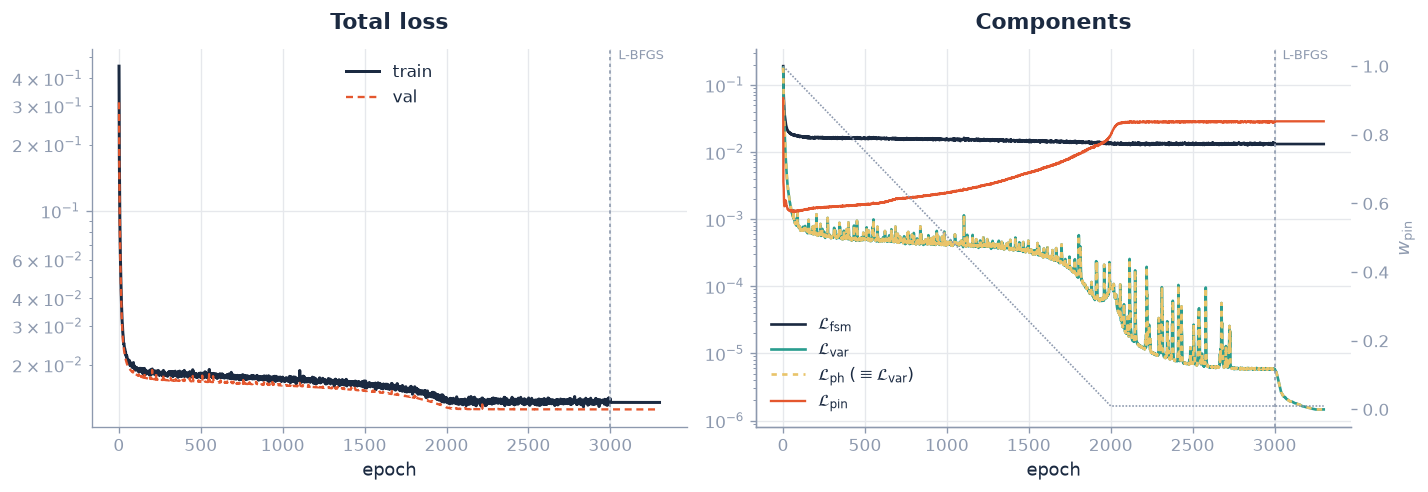

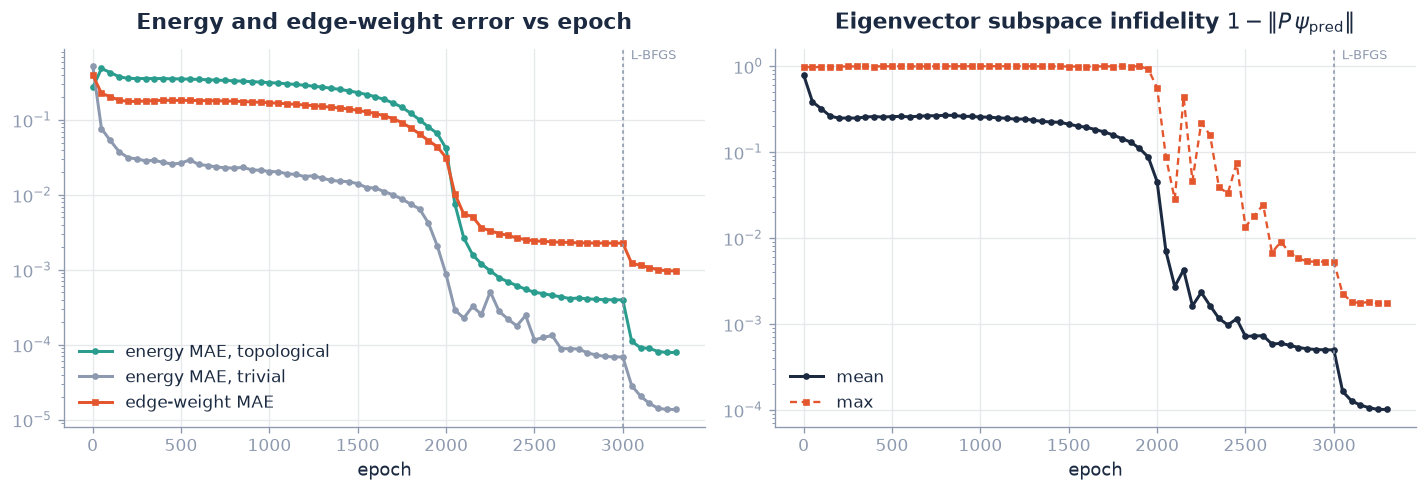

In [8]:
epochs = range(1, len(history["train_loss"]) + 1)
split = TWO_PHASE.adam_epochs  # AdamW -> L-BFGS hand-over


def _mark_phase_split(ax, top=True):
    ax.axvline(split, color=SLATE, ls=(0, (2, 2)), lw=1.0)
    ax.text(
        split,
        ax.get_ylim()[1] if top else ax.get_ylim()[0],
        "  L-BFGS",
        ha="left",
        va="top" if top else "bottom",
        fontsize=8,
        color=SLATE,
    )


# --- Figure 1: loss history and components ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(epochs, history["train_loss"], color=INK, lw=1.8, label="train")
if "val_loss" in history:
    axes[0].plot(
        epochs, history["val_loss"], color=CORAL, lw=1.4, ls=(0, (3, 2)), label="val"
    )
axes[0].set_yscale("log")
axes[0].set_title("Total loss")
axes[0].set_xlabel("epoch")
_mark_phase_split(axes[0])
axes[0].legend()

axes[1].plot(
    epochs, history["train_fsm"], color=INK, lw=1.6, label=r"$\mathcal{L}_{\rm fsm}$"
)
axes[1].plot(
    epochs, history["train_var"], color=TEAL, lw=1.6, label=r"$\mathcal{L}_{\rm var}$"
)
axes[1].plot(
    epochs,
    history["train_ph"],
    color=GOLD,
    lw=1.6,
    ls=(0, (2, 2)),
    label=r"$\mathcal{L}_{\rm ph}\;(\equiv \mathcal{L}_{\rm var})$",
)
axes[1].plot(
    epochs, history["train_pin"], color=CORAL, lw=1.4, label=r"$\mathcal{L}_{\rm pin}$"
)
axes[1].set_yscale("log")
axes[1].set_title("Components")
axes[1].set_xlabel("epoch")
_mark_phase_split(axes[1])
axes[1].legend(loc="lower left")

wt = axes[1].twinx()
wt.plot(epochs, history["train_pin_wt"], color=SLATE, lw=1.0, ls=(0, (1, 1)))
wt.set_ylabel(r"$w_{\rm pin}$", color=SLATE)
wt.set_ylim(-0.05, 1.05)
wt.tick_params(axis="y", colors=SLATE)
wt.grid(False)

fig.tight_layout()
fig.savefig(session.path() / "loss_history.png", bbox_inches="tight")

# --- Figure 2: physical errors recorded by the probe ----------------------
p_epoch = np.asarray(history["probe_epoch"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(
    p_epoch,
    history["probe_e_mae_topological"],
    color=TEAL,
    lw=1.8,
    marker="o",
    ms=3,
    label="energy MAE, topological",
)
axes[0].plot(
    p_epoch,
    history["probe_e_mae_trivial"],
    color=SLATE,
    lw=1.8,
    marker="o",
    ms=3,
    label="energy MAE, trivial",
)
axes[0].plot(
    p_epoch,
    history["probe_edge_mae"],
    color=CORAL,
    lw=1.8,
    marker="s",
    ms=3,
    label="edge-weight MAE",
)
axes[0].set_yscale("log")
axes[0].set_title("Energy and edge-weight error vs epoch")
axes[0].set_xlabel("epoch")
_mark_phase_split(axes[0])
axes[0].legend()

axes[1].plot(
    p_epoch,
    history["probe_subspace_infidelity"],
    color=INK,
    lw=1.8,
    marker="o",
    ms=3,
    label="mean",
)
axes[1].plot(
    p_epoch,
    history["probe_subspace_infidelity_max"],
    color=CORAL,
    lw=1.4,
    ls=(0, (3, 2)),
    marker="s",
    ms=3,
    label="max",
)
axes[1].set_yscale("log")
axes[1].set_title(r"Eigenvector subspace infidelity $1 - \|P\,\psi_{\rm pred}\|$")
axes[1].set_xlabel("epoch")
_mark_phase_split(axes[1])
axes[1].legend()

fig.tight_layout()
fig.savefig(session.path() / "probe_history.png", bbox_inches="tight")

### B. Lowest eigenvalue

Figure 3 compares $|E_R(\mu)|$ with exact diagonalisation across
$\mu \in [-4t, 4t]$ -- the near-zero mode throughout $|\mu| < 2t$ and the
linear approach $E \to |\mu| - 2t$ beyond. The inset shows the absolute
error on a logarithmic scale; the per-phase MAE is in the log output.

findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 600, now using 700.
2026-08-28 07:07:16 | INFO | nambu-fsm-baseline | |E_R(mu)| MAE over [-4t, 4t]:    4.9178e-05
2026-08-28 07:07:16 | INFO | nambu-fsm-baseline | E MAE, topological (|mu| < 2t): 7.9152e-05
2026-08-28 07:07:16 | INFO | nambu-fsm-baseline | E MAE, trivial     (|mu| > 2t): 1.9203e-05


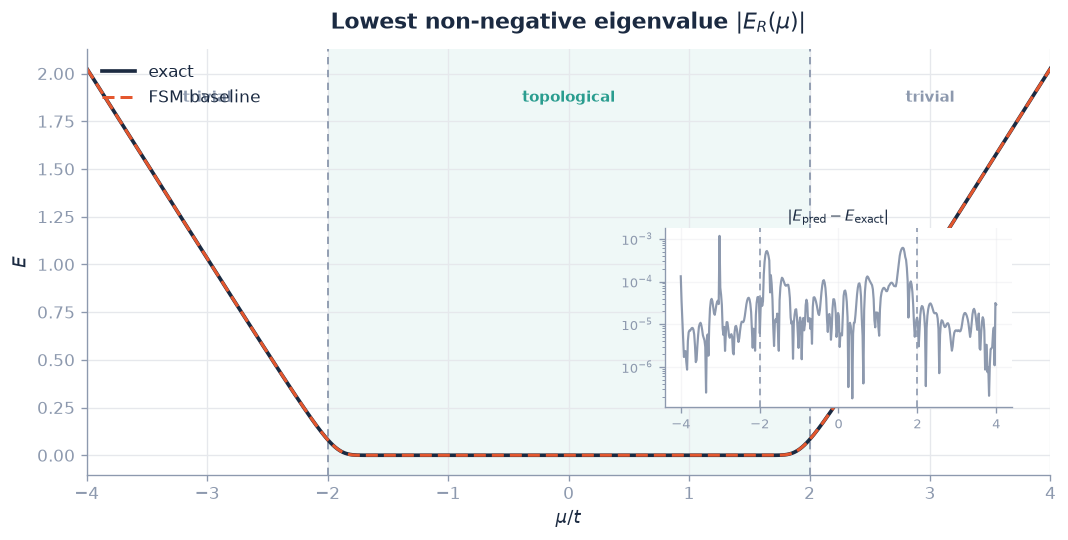

In [9]:
adapter = RayleighEnergyAdapter(trained_model, n_sites=N, hopping=t, pairing=delta).to(
    accelerator.device
)
adapter.eval()

mu_sweep = np.linspace(-4.0, 4.0, 400)
with torch.no_grad():
    mu_tensor = torch.tensor(
        mu_sweep[:, None], dtype=torch.float32, device=accelerator.device
    )
    e_pred_t, psi_pred_t = adapter(mu_tensor)
e_pred = np.abs(e_pred_t.cpu().numpy().ravel())  # |E_R|: the pin is soft
psi_pred = psi_pred_t.cpu().numpy()

e_exact = np.array(
    [np.linalg.eigvalsh(hamiltonian.build(float(m)))[N] for m in mu_sweep]
)
abs_err = np.abs(e_pred - e_exact)
topo = np.abs(mu_sweep) < 2 * t

fig, ax = plt.subplots(figsize=(9, 4.6))
_mark_topological(ax, t, 4.0)
ax.plot(mu_sweep, e_exact, color=INK, lw=2.2, label="exact")
ax.plot(mu_sweep, e_pred, color=CORAL, lw=1.8, ls=(0, (4, 2)), label="FSM baseline")
ax.fill_between(mu_sweep, e_exact, e_pred, color=CORAL, alpha=0.12, lw=0)
ax.set_title(r"Lowest non-negative eigenvalue $|E_R(\mu)|$")
ax.set_xlabel(r"$\mu / t$")
ax.set_ylabel(r"$E$")
_annotate_phases(ax, t, y=ax.get_ylim()[1] * 0.88)
ax.legend(loc="upper left")

inset = ax.inset_axes([0.60, 0.16, 0.36, 0.42])
inset.plot(mu_sweep, abs_err, color=SLATE, lw=1.3)
for x in (-2 * t, 2 * t):
    inset.axvline(x, color=SLATE, ls=(0, (4, 3)), lw=1.0)
inset.set_yscale("log")
inset.set_title(r"$|E_{\rm pred} - E_{\rm exact}|$", fontsize=9, pad=4)
inset.tick_params(labelsize=8)
inset.grid(True, alpha=0.4)

fig.tight_layout()
fig.savefig(session.path() / "energy_sweep.png", bbox_inches="tight")

session.info(f"|E_R(mu)| MAE over [-4t, 4t]:    {abs_err.mean():.4e}")
session.info(f"E MAE, topological (|mu| < 2t): {abs_err[topo].mean():.4e}")
session.info(f"E MAE, trivial     (|mu| > 2t): {abs_err[~topo].mean():.4e}")

### C. Eigenvector fidelity and edge localisation

The left panel of Fig. 4 reports $\lVert P\,\psi_{\mathrm{pred}} \rVert$, the
projection of the prediction onto the span of the two exact eigenvectors of
smallest $|E|$ -- the well-defined accuracy measure where the
$\pm\lambda_1$ pair is degenerate. The right panel shows the combined
particle and hole weight on the two outermost sites at each end.

2026-08-28 07:07:16 | INFO | nambu-fsm-baseline | mean subspace fidelity: 0.9999  (min 0.9921)
2026-08-28 07:07:16 | INFO | nambu-fsm-baseline | edge-weight MAE: 9.7240e-04


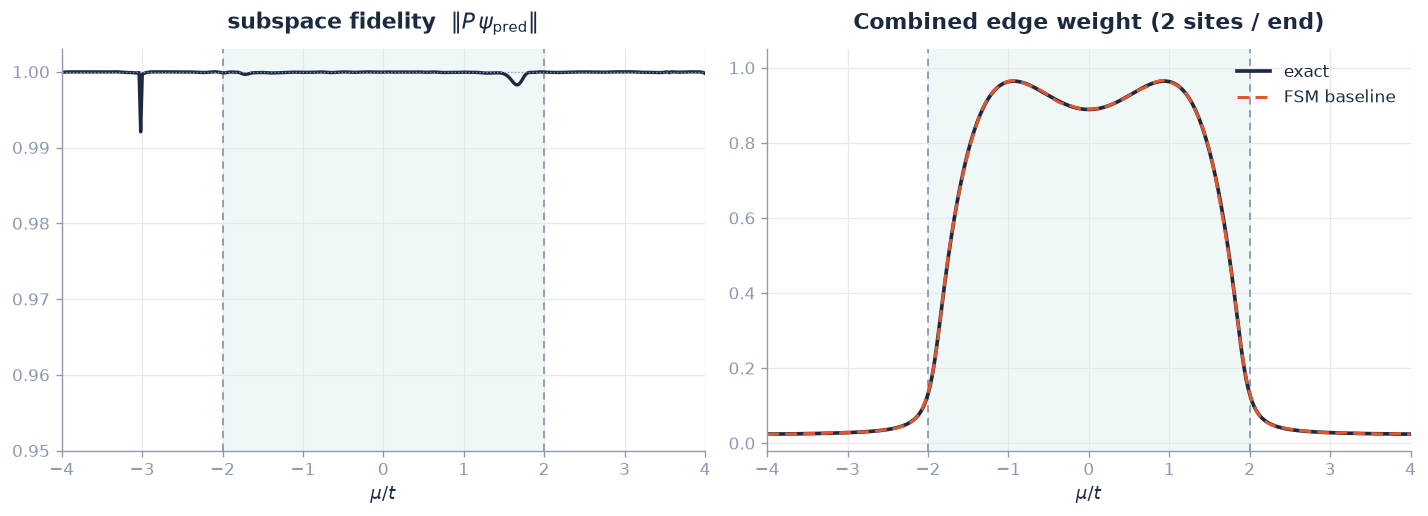

In [10]:
n_edge = 2
edge_idx = np.r_[0:n_edge, N - n_edge : N]

subspace_fidelity = np.empty_like(mu_sweep)
edge_exact = np.empty_like(mu_sweep)
for i, m in enumerate(mu_sweep):
    w, V = np.linalg.eigh(hamiltonian.build(float(m)))
    near_zero = V[:, np.argsort(np.abs(w))[:2]]  # the +/- lambda_min pair
    subspace_fidelity[i] = np.linalg.norm(near_zero.T @ psi_pred[i])
    psi_e = V[:, N]
    edge_exact[i] = (psi_e[:N][edge_idx] ** 2).sum() + (psi_e[N:][edge_idx] ** 2).sum()

prob_pred = psi_pred**2
edge_pred = prob_pred[:, :N][:, edge_idx].sum(1) + prob_pred[:, N:][:, edge_idx].sum(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

_mark_topological(axes[0], t, 4.0)
axes[0].plot(mu_sweep, subspace_fidelity, color=INK, lw=2.0)
axes[0].set_ylim(min(0.95, subspace_fidelity.min() - 0.01), 1.003)
axes[0].axhline(1.0, color=SLATE, lw=0.8, ls=":")
axes[0].set_title(r"subspace fidelity  $\|P\,\psi_{\rm pred}\|$")
axes[0].set_xlabel(r"$\mu / t$")

_mark_topological(axes[1], t, 4.0)
axes[1].plot(mu_sweep, edge_exact, color=INK, lw=2.2, label="exact")
axes[1].plot(
    mu_sweep, edge_pred, color=CORAL, lw=1.8, ls=(0, (4, 2)), label="FSM baseline"
)
axes[1].set_title("Combined edge weight (2 sites / end)")
axes[1].set_xlabel(r"$\mu / t$")
axes[1].set_ylim(-0.02, 1.05)
axes[1].legend(loc="upper right")

fig.tight_layout()
fig.savefig(session.path() / "eigenvector_agreement.png", bbox_inches="tight")

session.info(
    f"mean subspace fidelity: {subspace_fidelity.mean():.4f}  "
    f"(min {subspace_fidelity.min():.4f})"
)
session.info(f"edge-weight MAE: {np.abs(edge_pred - edge_exact).mean():.4e}")

### D. Probability densities

Figure 5 shows the particle- and hole-sector densities $|\psi_n|^2$ at
$\mu = \pm 3.4\,t$ (deep trivial), $\pm 1.0\,t$ (topological), and $0$.

The trivial-phase columns are a genuine test and agree closely. **The
topological columns are not a well-posed per-site comparison.** Throughout
$|\mu| \lesssim 1.5\,t$ the $\pm\lambda_1$ pair is degenerate to
$\lambda_1 \approx 2\times10^{-5}$ (the next gap is of order $t$), so
$\lVert H\psi \rVert \approx \lambda_1$ for *every* unit vector in the
two-dimensional near-zero subspace:
$\mathcal{L}_{\mathrm{fsm}} + \mathcal{L}_{\mathrm{var}}$ is flat over that
whole plane and gives the network no gradient selecting one rotation within
it. Figure 4 (left) confirms the prediction stays in the correct subspace to
$\lVert P\,\psi_{\mathrm{pred}} \rVert \gtrsim 0.99$ everywhere; *which*
combination of the two Majorana end modes it then represents is undetermined
by the loss and need not match the vector `numpy.linalg.eigh` returns (which
is itself only defined up to that same rotation, and which LAPACK flips
between the two basis directions at scattered $\mu$). Because `SirenPINN`
has no $\mu \to -\mu$ fold, the two halves of the domain are optimised
independently, so the undetermined rotation can differ between $+\mu$ and
$-\mu$ -- visible here as the lopsided topological profile at
$\mu = -1.0\,t$ against the balanced one at $\mu = +1.0\,t$.

Everything subspace-invariant is unaffected: the energy (Fig. 3), the
combined edge weight (Fig. 4, right; a sum over both ends), and the subspace
fidelity itself all agree to their reported tolerances. Pinning an
*individual* vector within the degenerate plane is exactly what the
structural Nambu and chiral notebooks add.

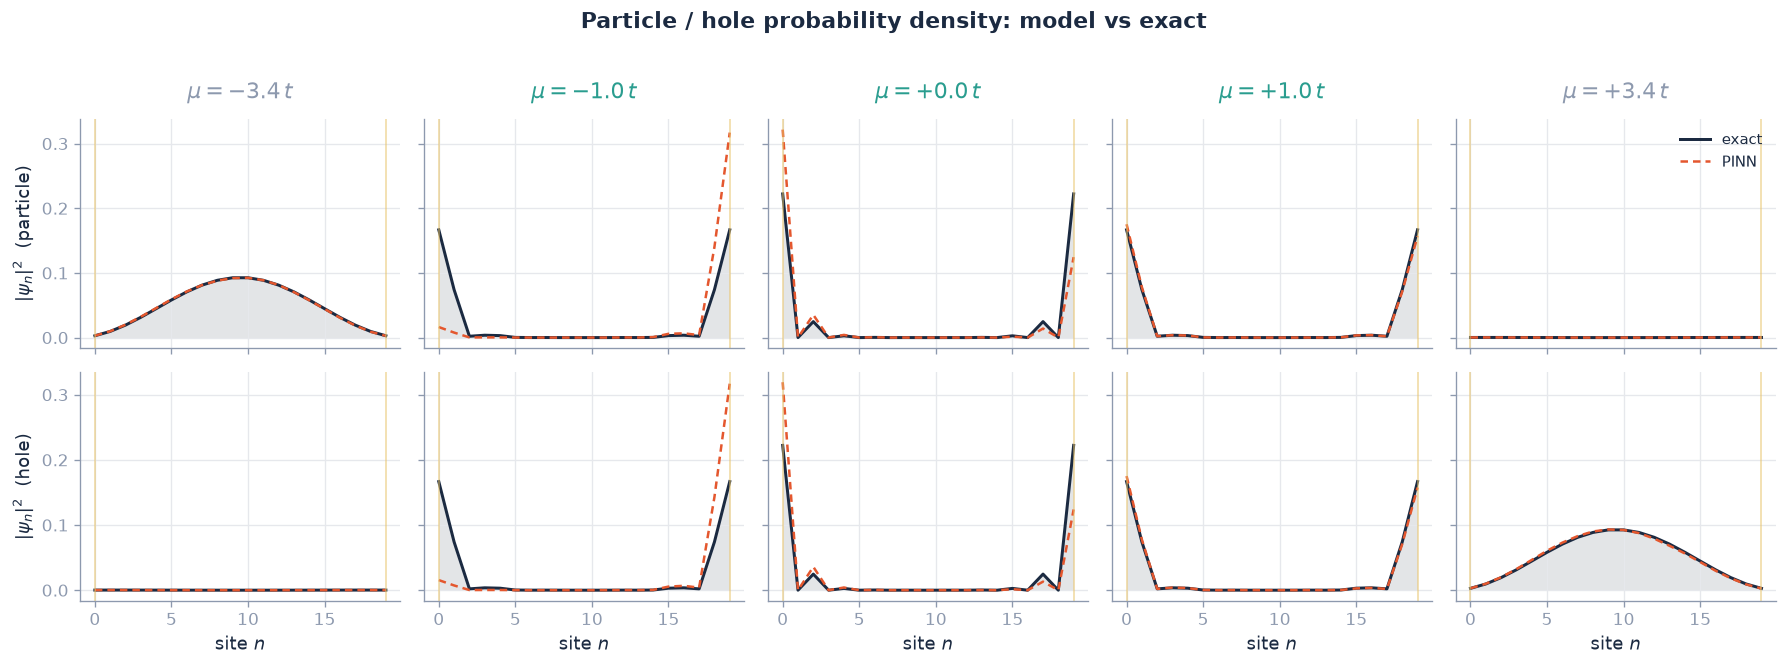

In [11]:
probe_mus = [-3.4, -1.0, 0.0, 1.0, 3.4]
wf = sweep_wavefunctions(adapter, hamiltonian, probe_mus, device=accelerator.device)

fig, axes = plt.subplots(
    2, len(probe_mus), figsize=(3.0 * len(probe_mus), 5.4), sharex=True, sharey="row"
)
sites = wf.sites

for col, mu in enumerate(probe_mus):
    topo = abs(mu) < 2 * t
    tag_color = TEAL if topo else SLATE
    for row, (exact, pred, label) in enumerate(
        (
            (wf.particle_exact[col], wf.particle_pred[col], "particle"),
            (wf.hole_exact[col], wf.hole_pred[col], "hole"),
        )
    ):
        ax = axes[row, col]
        ax.fill_between(sites, exact, color=INK, alpha=0.12, lw=0)
        ax.plot(sites, exact, color=INK, lw=1.8, label="exact")
        ax.plot(sites, pred, color=CORAL, lw=1.5, ls=(0, (3, 2)), label="PINN")
        for edge in (0, N - 1):
            ax.axvline(edge, color=GOLD, lw=1.0, alpha=0.6)
        if row == 0:
            ax.set_title(rf"$\mu = {mu:+.1f}\,t$", color=tag_color)
        if col == 0:
            ax.set_ylabel(rf"$|\psi_n|^2$  ({label})")
        if row == 1:
            ax.set_xlabel("site $n$")

axes[0, -1].legend(loc="upper right", fontsize=9)
fig.suptitle(
    "Particle / hole probability density: model vs exact",
    y=1.02,
    fontsize=13,
    weight="600",
)
fig.tight_layout()
fig.savefig(session.path() / "wavefunctions.png", bbox_inches="tight")

### E. Learned reflection symmetry

`SirenPINN` has no $\mu \to -\mu$ fold, so $E(-\mu) = E(\mu)$ is a property
the network must learn from the two-sided sampling rather than one it is
given. Figure 6 overlays $E_R(\mu)$ and $E_R(-\mu)$ over $[0, 4t]$; the
residual $|E_R(-\mu) - E_R(\mu)|$ is reported in the log output. Unlike the
chiral notebook's Fig. 6 (agreement to floating-point tolerance, by
construction), a nonzero residual here is expected.

2026-08-28 07:07:17 | INFO | nambu-fsm-baseline | max |E_R(-mu) - E_R(mu)| (learned): 6.210e-04


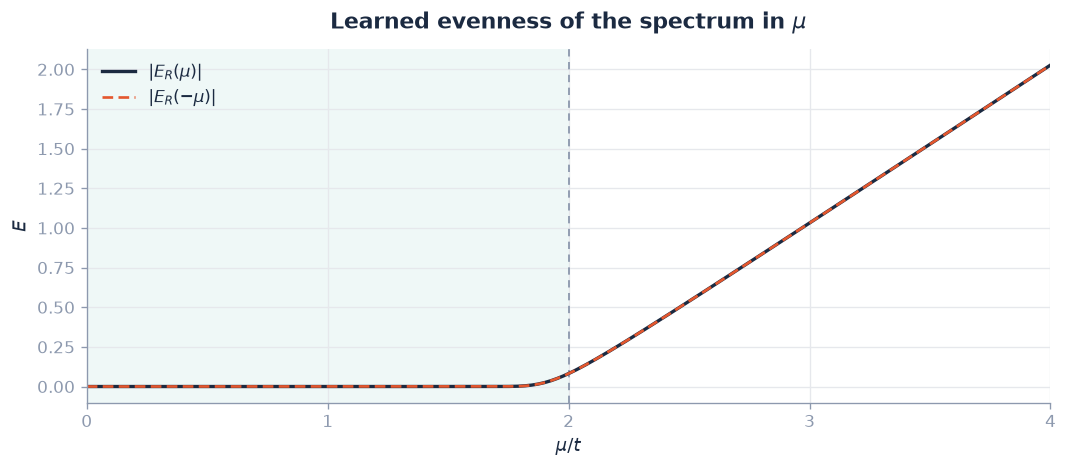

In [12]:
half = np.linspace(0.0, 4.0, 300)
with torch.no_grad():
    pos = torch.tensor(half[:, None], dtype=torch.float32, device=accelerator.device)
    e_pos = np.abs(adapter(pos)[0].cpu().numpy().ravel())
    e_neg = np.abs(adapter(-pos)[0].cpu().numpy().ravel())

fig, ax = plt.subplots(figsize=(9, 4.0))
_mark_topological(ax, t, 4.0)
ax.set_xlim(0, 4.0)
ax.plot(half, e_pos, color=INK, lw=2.0, label=r"$|E_R(\mu)|$")
ax.plot(half, e_neg, color=CORAL, lw=1.6, ls=(0, (4, 2)), label=r"$|E_R(-\mu)|$")
ax.set_title(r"Learned evenness of the spectrum in $\mu$")
ax.set_xlabel(r"$\mu / t$")
ax.set_ylabel(r"$E$")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(session.path() / "mu_reflection.png", bbox_inches="tight")

session.info(f"max |E_R(-mu) - E_R(mu)| (learned): {np.abs(e_neg - e_pos).max():.3e}")

## VIII. Summary

The single-head SIREN enforces only $\lVert \psi \rVert = 1$ and learns
everything else from a four-term loss with an annealed pin. Two of those
terms are not independent -- `loss_ph` equals `loss_var` identically because
$\Xi H \Xi = -H$ (Fig. 1) -- and `loss_pin` is a soft substitute for an
energy-sign guarantee the chiral model obtains for free. Trained in two
stages over $-4t < \mu < 4t$ (AdamW streaming, then L-BFGS on a fixed pool,
with the epoch count continued so the pin schedule does not restart), the
model is accurate on every gauge-invariant quantity: the lowest eigenvalue
(Fig. 3), the combined edge weight (Fig. 4, right), the subspace fidelity
$\lVert P\,\psi_{\mathrm{pred}} \rVert$ (Fig. 4, left), and the learned
evenness in $\mu$ (Fig. 6). The probe curves (Fig. 2) show these errors
falling through the plateau of the total loss.

Its one structural limitation is on display in Fig. 5: in the topological
phase the near-zero pair is degenerate to $\sim\!10^{-5}$, so the loss is
flat over the entire two-dimensional Majorana subspace and cannot select an
individual vector within it. The prediction lands in that subspace but on an
arbitrary rotation, which -- with no $\mu \to -\mu$ fold to couple the two
halves -- can differ between $+\mu$ and $-\mu$. This is not fixed by more
sampling or a longer run; it is fixed by parametrising the problem so that
the individual vector *is* determined, which is exactly what the structural
Nambu notebook (drop `loss_ph` and `loss_pin`, keep `fsm + var`, fold the
domain to $[0, 4t]$) and the chiral-basis notebook do. This run is their
reference point.